<a href="https://colab.research.google.com/github/HarshRaj3112007/100-Days-of-ML/blob/main/Random_sample_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv("train.csv",usecols=['Age','Fare','Survived'])

In [4]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2)

In [7]:
X_train

,Age,Fare
23,28.0,35.5000
735,28.5,16.1000
196,NaN,7.7500
863,NaN,69.5500
617,26.0,16.1000
...,...,...
667,NaN,7.7750
854,44.0,26.0000
471,38.0,8.6625
433,17.0,7.1250


In [11]:
X_train.isnull().sum()

,0
Age,133
Fare,0


In [19]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [20]:
X_train

,Age,Fare,Age_imputed
23,28.0,35.5000,28.0
735,28.5,16.1000,28.5
196,NaN,7.7500,NaN
863,NaN,69.5500,NaN
617,26.0,16.1000,26.0
...,...,...,...
667,NaN,7.7750,NaN
854,44.0,26.0000,44.0
471,38.0,8.6625,38.0
433,17.0,7.1250,17.0


In [21]:
mask = X_train['Age_imputed'].isnull()
X_train.loc[mask, 'Age_imputed'] = X_train['Age'].dropna().sample(mask.sum()).values

In [22]:
X_train

,Age,Fare,Age_imputed
23,28.0,35.5000,28.0
735,28.5,16.1000,28.5
196,NaN,7.7500,13.0
863,NaN,69.5500,28.0
617,26.0,16.1000,26.0
...,...,...,...
667,NaN,7.7750,28.0
854,44.0,26.0000,44.0
471,38.0,8.6625,38.0
433,17.0,7.1250,17.0


In [23]:
import seaborn as sns

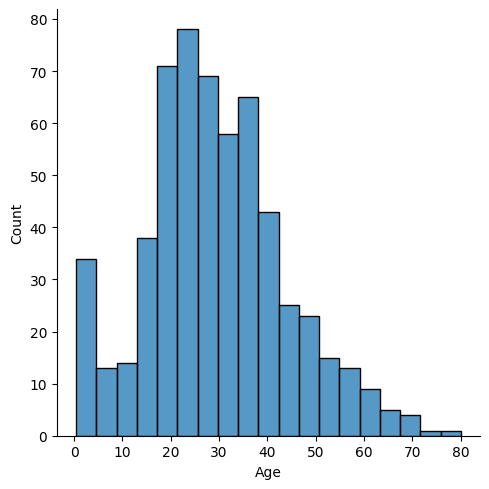

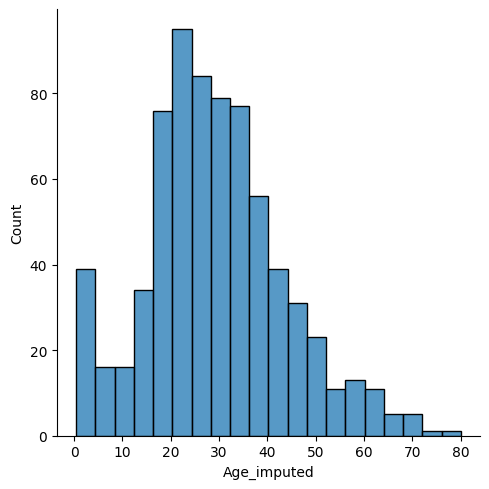

In [27]:
sns.displot(X_train['Age'])
sns.displot(X_train['Age_imputed'])

<Axes: xlabel='Age', ylabel='Density'>

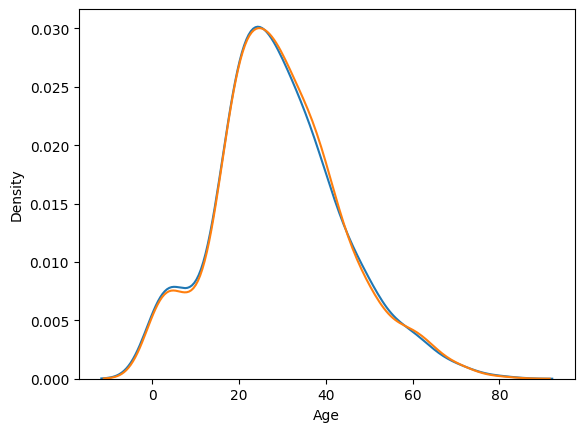

In [30]:
sns.kdeplot(X_train['Age'])
sns.kdeplot(X_train['Age_imputed'])

In [31]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  210.43053993999922
Variance after random imputation:  207.51607986990155


In [32]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2311.824714,71.040579,58.498155
Age,71.040579,210.430540,210.430540
Age_imputed,58.498155,210.430540,207.516080


<Axes: >

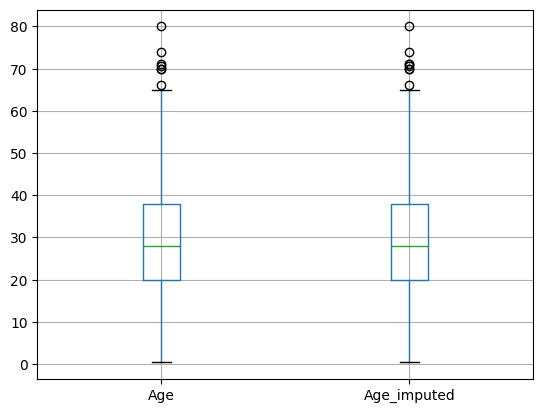

In [33]:
X_train[['Age', 'Age_imputed']].boxplot()

In [35]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=42)

# For categorical data

In [37]:
dt = pd.read_csv('/content/house-train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [38]:
dt

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [39]:
dt.isnull().sum()

,0
FireplaceQu,690
GarageQual,81
SalePrice,0


In [40]:
X = dt.drop(columns=['SalePrice'])
y = dt['SalePrice']

In [41]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2)

In [42]:
X_train['GarageQual_Imputed'] = X_train['GarageQual']
X_test['FireplaceQu_Imputed'] = X_test['FireplaceQu']

In [45]:
mask1 = X_train['GarageQual_Imputed'].isnull()
X_train.loc[mask, 'GarageQual_Imputed'] = X_train['GarageQual'].dropna().sample(mask.sum()).values

In [48]:
X_train['FireplaceQu_Imputed'] = X_train['FireplaceQu']
mask2 = X_train['FireplaceQu_Imputed'].isnull()
X_train.loc[mask2, 'FireplaceQu_Imputed'] = X_train['FireplaceQu'].dropna().sample(mask2.sum(), random_state=42).values

In [49]:
X_train

,FireplaceQu,GarageQual,GarageQual_Imputed,FireplaceQu_Imputed
202,NaN,TA,TA,TA
811,Gd,TA,TA,Gd
1431,NaN,TA,TA,TA
46,Ex,TA,TA,Ex
119,Gd,TA,TA,Gd
...,...,...,...,...
810,Fa,TA,TA,Fa
210,NaN,NaN,TA,TA
1381,Gd,TA,TA,Gd
560,Gd,TA,TA,Gd


<Axes: xlabel='count', ylabel='GarageQual_Imputed'>

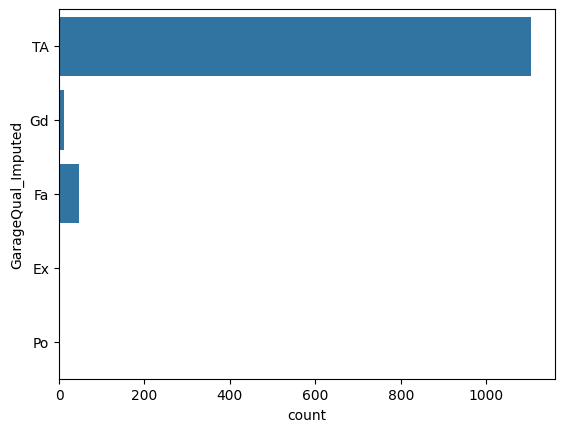

In [50]:
sns.countplot(X_train['GarageQual_Imputed'])

<Axes: xlabel='count', ylabel='FireplaceQu_Imputed'>

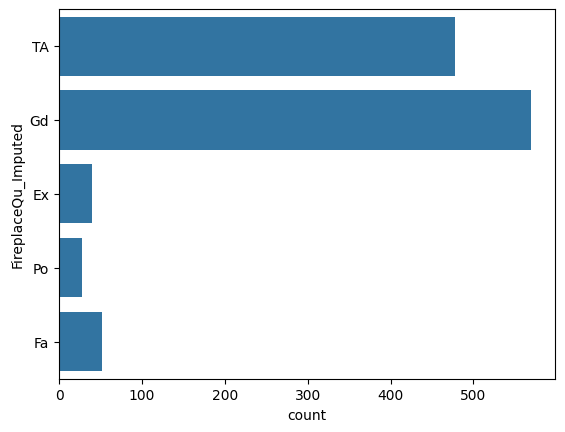

In [51]:
sns.countplot(X_train['FireplaceQu_Imputed'])

In [53]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_Imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [54]:
temp

,original,imputed
TA,0.947177,0.946918
Fa,0.040073,0.040240
Gd,0.010018,0.010274
Ex,0.001821,0.001712
Po,0.000911,0.000856


In [57]:
temp1 = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_Imputed'].value_counts() / len(df)
        ],
        axis=1)

temp1.columns = ['original', 'imputed']

temp1

,original,imputed
Gd,0.490323,0.639731
TA,0.403226,0.536476
Fa,0.046774,0.058361
Ex,0.035484,0.044893
Po,0.024194,0.031425


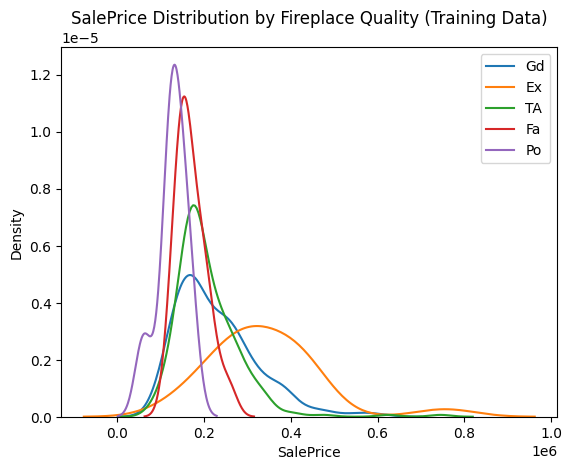

In [60]:
import matplotlib.pyplot as plt


plot_df = pd.concat([X_train['FireplaceQu'], Y_train], axis=1)

for category in plot_df['FireplaceQu'].dropna().unique():
    sns.kdeplot(plot_df[plot_df['FireplaceQu'] == category]['SalePrice'], label=category)

plt.legend()
plt.title('SalePrice Distribution by Fireplace Quality (Training Data)')
plt.show()

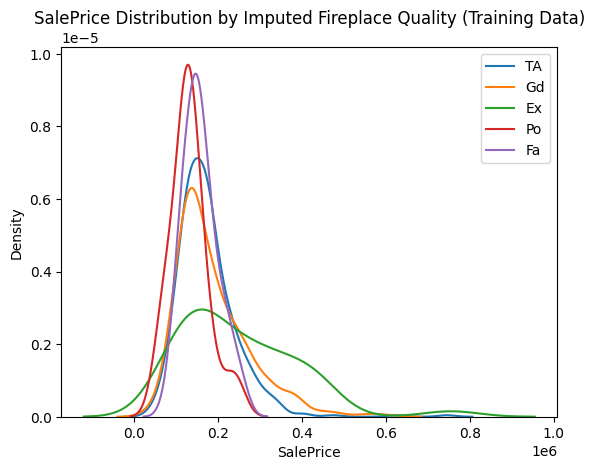

In [61]:
import matplotlib.pyplot as plt


plot_df_imputed = pd.concat([X_train['FireplaceQu_Imputed'], Y_train], axis=1)

for category in plot_df_imputed['FireplaceQu_Imputed'].dropna().unique():
    sns.kdeplot(plot_df_imputed[plot_df_imputed['FireplaceQu_Imputed'] == category]['SalePrice'], label=category)

plt.legend()
plt.title('SalePrice Distribution by Imputed Fireplace Quality (Training Data)')
plt.show()

In [ ]:
# this wont perform good on fireplacequ since it is distorting our kdeplot.